In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/AB_NYC_2019.csv.zip')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [22]:
 df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [23]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [24]:
missing_count = df.isnull().sum()
missing_df = (df.isnull().sum()/len(df))*100
print(missing_df)

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


In [25]:
cat_cols = df.select_dtypes(include = 'object').columns
cat_cols

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='object')

In [26]:
num_cols = df.select_dtypes(exclude = 'object').columns
num_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [27]:
df = df.drop(columns = ['last_review'])

In [28]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [29]:
df = df.drop(columns = ['id', 'name', 'host_id', 'host_name'])

In [30]:
print(df.isnull().sum())

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


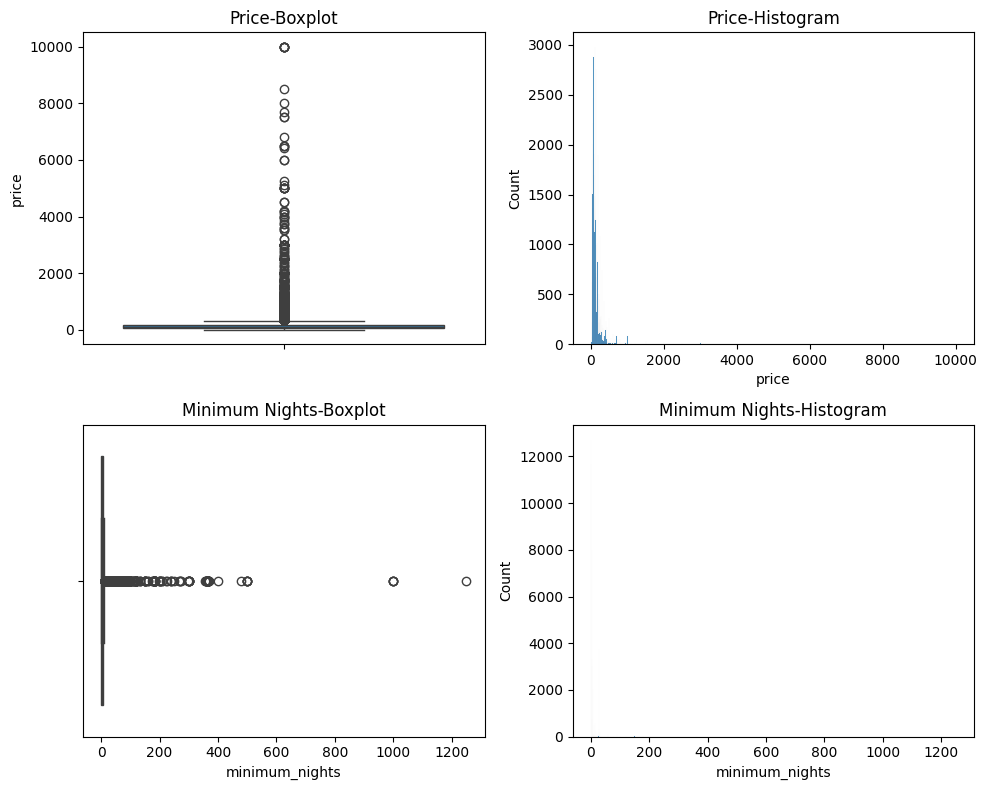

In [32]:
fig, axes = plt.subplots(2, 2, figsize = (10,8))
sns.boxplot(df['price'], ax = axes[0,0])
axes[0,0].set_title('Price-Boxplot')
sns.histplot(df['price'], ax = axes[0,1])
axes[0,1].set_title('Price-Histogram')

sns.boxplot(x=df['minimum_nights'], ax = axes[1,0])
axes[1,0].set_title('Minimum Nights-Boxplot')
sns.histplot(df['minimum_nights'], ax = axes[1,1])
axes[1,1].set_title('Minimum Nights-Histogram')
plt.tight_layout()
plt.show()

In [33]:
print("Price percentile:")
print(df['price'].describe())
print(f"95th percentile: {df['price'].quantile(0.95)}")
print(f"99th percentile: {df['price'].quantile(0.99)}")
print("\nMinimum Nights percentile:")
print(df['minimum_nights'].describe())
print(f"95th percentile: {df['minimum_nights'].quantile(0.95)}")
print(f"99th percentile: {df['minimum_nights'].quantile(0.99)}")

Price percentile:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64
95th percentile: 355.0
99th percentile: 799.0

Minimum Nights percentile:
count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64
95th percentile: 30.0
99th percentile: 45.0


In [34]:
price_cap = df['price'].quantile(0.99)
night_cap = df['minimum_nights'].quantile(0.95)
print(f"Price Cap: {price_cap}")
print(f"Minimum Nights Cap: {night_cap}")
print(f"Number of rows before filtering: {len(df)}")
df = df[(df['price'] < price_cap) & (df['minimum_nights'] < night_cap)]
df = df[df['price']>0]
print(f"rows after:{len(df)}")

Price Cap: 799.0
Minimum Nights Cap: 30.0
Number of rows before filtering: 48895
rows after:43961


In [35]:
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [36]:
x = df.drop('price', axis = 1)
y = df['price']

In [38]:
x.select_dtypes(include = 'object').columns

Index(['neighbourhood_group', 'neighbourhood', 'room_type'], dtype='object')

In [39]:
df = df.drop(columns = ['neighbourhood'])

In [40]:
x = pd.get_dummies(
    x,
    columns = ['neighbourhood_group', 'room_type'],
    drop_first = True
)

In [41]:
print(x.shape)
print(y.shape)
x.head()

(43961, 14)
(43961,)


,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,Kensington,40.64749,-73.97237,1,9,0.21,6,365,True,False,False,False,True,False
1,Midtown,40.75362,-73.98377,1,45,0.38,2,355,False,True,False,False,False,False
2,Harlem,40.80902,-73.94190,3,0,0.00,1,365,False,True,False,False,True,False
3,Clinton Hill,40.68514,-73.95976,1,270,4.64,1,194,True,False,False,False,False,False
4,East Harlem,40.79851,-73.94399,10,9,0.10,1,0,False,True,False,False,False,False


In [42]:
x.columns


Index(['neighbourhood', 'latitude', 'longitude', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan',
       'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island',
       'room_type_Private room', 'room_type_Shared room'],
      dtype='object')

In [43]:
x = x.drop(columns =['neighbourhood'])

In [44]:
x = df.drop('price', axis = 1)
y = df['price']

In [45]:
x = pd.get_dummies(
    x,
    columns = ['neighbourhood_group', 'room_type'],
    drop_first = True
)

In [46]:
print(x.shape)
print(x.dtypes)

(43961, 13)
latitude                             float64
longitude                            float64
minimum_nights                         int64
number_of_reviews                      int64
reviews_per_month                    float64
calculated_host_listings_count         int64
availability_365                       int64
neighbourhood_group_Brooklyn            bool
neighbourhood_group_Manhattan           bool
neighbourhood_group_Queens              bool
neighbourhood_group_Staten Island       bool
room_type_Private room                  bool
room_type_Shared room                   bool
dtype: object


In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)
print("x_train:",x_train.shape)
print("x_test:",x_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

x_train: (35168, 13)
x_test: (8793, 13)
y_train: (35168,)
y_test: (8793,)


In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [50]:
y_pred = lr.predict(x_test)

In [52]:
from sklearn.metrics import(

 r2_score,
mean_absolute_error,
mean_squared_error)
import numpy as np
print("R2 Score:",r2_score(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.36499948260725656
MAE: 51.4901031558325
MSE: 6734.591718882963
RMSE: 82.06455823851708


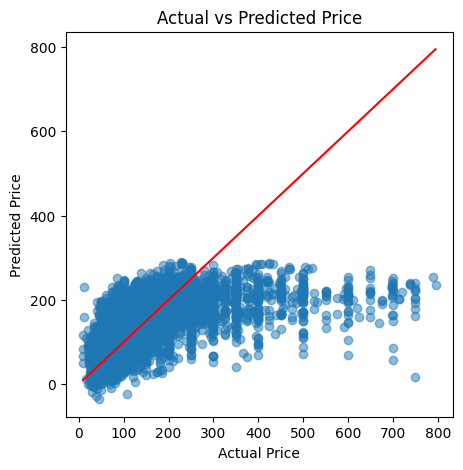

In [53]:
plt.figure(figsize = (5,5))
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color = 'red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

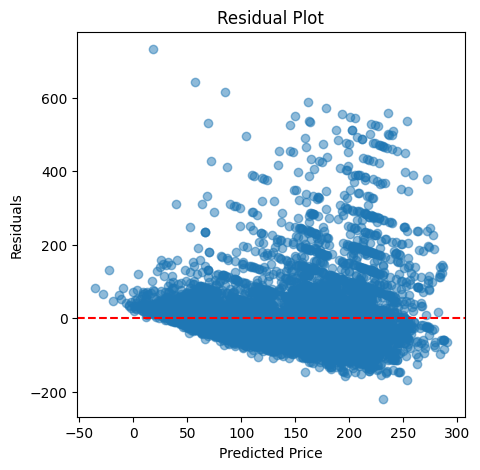

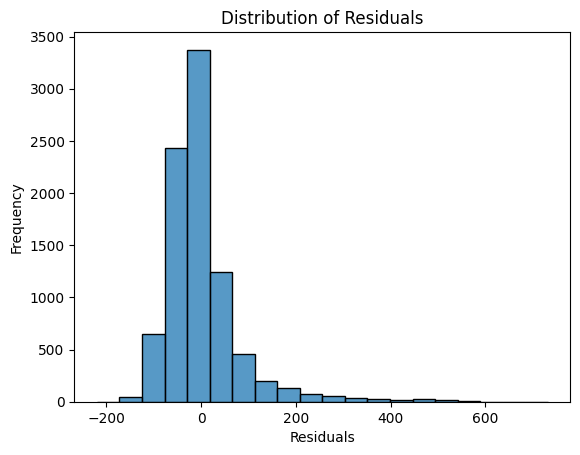

In [54]:
residuals = y_test - y_pred
plt.figure(figsize = (5,5))
plt.scatter(y_pred, residuals, alpha = 0.5)
plt.axhline(y = 0, color = 'red', linestyle = '--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
sns.histplot(residuals, bins = 20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()